<a href="https://colab.research.google.com/github/Claudio-Ferriz/Proyecto-AP-PS/blob/main/Proyecto_AP_PS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [84]:
# Importación y ejecución de las librerías de Python para el análisis y modelado
# de datos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataframes

In [85]:
# Generación del primer dataframe referido a Aprobación Presidencial el cual
# se encuentra en formato excel importando desde el repositorio
# github del proyecto.


df_ap = pd.read_excel('https://github.com/Claudio-Ferriz/Proyecto-AP-PS/raw/refs/heads/main/Copia%20de%20Encuestas%20Aprobaci%C3%B3n%20Presidencial%202025%20-%20Solo%20Base%20Integrada.xlsx')

# Eliminación de las columnas 'Unnamed' ya que no generan valor al df_ap.

unnamed_cols = [col for col in df_ap.columns if col.startswith('Unnamed')]

df_ap = df_ap.drop(columns=unnamed_cols)


In [86]:
# Generación del segundo dataframe referido a Protesta Social el cual
# se encuentra en formato excel importando desde el repositorio
# github del proyecto.


df_ps = pd.read_excel('https://github.com/Claudio-Ferriz/Proyecto-AP-PS/raw/refs/heads/main/Copia%20de%20Protesta_Social_Aggregated_Data_Up_To-2026-02-28.xlsx')


# Exploratory Data Analysis (EDA)

## Dataframe Aprobación Presidencial

In [87]:
df_ap

,País,Región I,Región II,Tipo de Encuesta,Consultora,Mes,Año,Fecha,Aprueba,Presidente,...,Tipo de Presidente,Fecha asunción,Días de presidencia,Presidencial / Parlamentario,Unitario o Federal,Población,Indice Desarrollo Humano,PBI per capita (PPA),Tasa Desempleo,Inflación
0,Alemania,Europa,Europa,Online,Televisión pública ARD,Abril,2020.0,2020-04-03,64.0,Angela Merkel,...,Insider,2005-11-22,5246.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.4
1,Alemania,Europa,Europa,Online,Civey,Mayo,2020.0,2020-05-06,61.0,Angela Merkel,...,Insider,2005-11-22,5279.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5
2,Alemania,Europa,Europa,Online,Civey,Mayo,2020.0,2020-05-21,64.0,Angela Merkel,...,Insider,2005-11-22,5294.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5
3,Alemania,Europa,Europa,Online,Infratest Dimap,Mayo,2020.0,2020-05-31,68.0,Angela Merkel,...,Insider,2005-11-22,5304.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5
4,Alemania,Europa,Europa,Online,Infratest Dimap,Junio,2020.0,2020-06-16,40.0,Angela Merkel,...,Insider,2005-11-22,5320.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,-0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2864,Colombia,América,América Latina,Presencial,CB consultora,Noviembre,2025.0,2025-11-20,36.7,Gustavo Petro,...,Maverick,2022-08-07,1201.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN
2865,Colombia,América,América Latina,Presencial,CB consultora,Octubre,2025.0,2025-10-22,38.1,Gustavo Petro,...,Maverick,2022-08-07,1172.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN
2866,Paraguay,América,América Latina,Presencial,CB consultora,Noviembre,2025.0,2025-11-22,41.3,Santiago Peña,...,Insider,2023-08-15,799.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN
2867,Perú,América,América Latina,Telefónica,CB consultora,Noviembre,2025.0,2025-11-24,32.5,José Jerí,...,Insider,2025-10-10,56.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN


In [88]:
df_ap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2869 entries, 0 to 2868
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   País                          2869 non-null   object        
 1   Región I                      2869 non-null   object        
 2   Región II                     2869 non-null   object        
 3   Tipo de Encuesta              2800 non-null   object        
 4   Consultora                    2828 non-null   object        
 5   Mes                           2869 non-null   object        
 6   Año                           2817 non-null   float64       
 7   Fecha                         2817 non-null   datetime64[ns]
 8   Aprueba                       2827 non-null   float64       
 9   Presidente                    2869 non-null   object        
 10  Partido del presidente        2869 non-null   object        
 11  Tipo de Presidente            

In [89]:
df_ap.isnull().sum()

,0
País,0
Región I,0
Región II,0
Tipo de Encuesta,69
Consultora,41
Mes,0
Año,52
Fecha,52
Aprueba,42
Presidente,0


In [90]:
# Transformación de los valores de la columna Año en el dataframe Aprobación
# Presidencial de Dtype float64 a Int64.

df_ap['Año'] = df_ap['Año'].astype('Int64')

#df_ap = df_ap.dropna(subset=['Año'])
#df_ap['Año'] = df_ap['Año'].astype('int64')

df_ap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2869 entries, 0 to 2868
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   País                          2869 non-null   object        
 1   Región I                      2869 non-null   object        
 2   Región II                     2869 non-null   object        
 3   Tipo de Encuesta              2800 non-null   object        
 4   Consultora                    2828 non-null   object        
 5   Mes                           2869 non-null   object        
 6   Año                           2817 non-null   Int64         
 7   Fecha                         2817 non-null   datetime64[ns]
 8   Aprueba                       2827 non-null   float64       
 9   Presidente                    2869 non-null   object        
 10  Partido del presidente        2869 non-null   object        
 11  Tipo de Presidente            

## Dataframe Protesta Social

In [91]:
df_ps

,Mes,Año,País,Tipo de Protesta,Cantidad de Eventos de Protesta
0,Septiembre,2020,Argentina,Battles,1
1,Mayo,2021,Argentina,Explosions/Remote violence,1
2,Julio,2018,Argentina,Explosions/Remote violence,2
3,Julio,2018,Argentina,Explosions/Remote violence,1
4,Noviembre,2018,Argentina,Explosions/Remote violence,1
...,...,...,...,...,...
170339,Noviembre,2021,Inglaterra,Riots,1
170340,Abril,2022,Inglaterra,Riots,1
170341,Diciembre,2022,Inglaterra,Riots,1
170342,Mayo,2023,Inglaterra,Riots,1


In [92]:
df_ps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170344 entries, 0 to 170343
Data columns (total 5 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Mes                              170344 non-null  object
 1   Año                              170344 non-null  int64 
 2   País                             170344 non-null  object
 3   Tipo de Protesta                 170344 non-null  object
 4   Cantidad de Eventos de Protesta  170344 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 6.5+ MB


In [93]:
df_ps.isnull().sum()

,0
Mes,0
Año,0
País,0
Tipo de Protesta,0
Cantidad de Eventos de Protesta,0


In [94]:
df_ps = df_ps.groupby(['Mes','Año','País'])['Cantidad de Eventos de Protesta'].sum().reset_index()

df_ps

,Mes,Año,País,Cantidad de Eventos de Protesta
0,Abril,2018,Argentina,230
1,Abril,2018,Bolivia,21
2,Abril,2018,Brasil,1379
3,Abril,2018,Chile,131
4,Abril,2018,Colombia,226
...,...,...,...,...
1569,Septiembre,2025,México,1292
1570,Septiembre,2025,Paraguay,151
1571,Septiembre,2025,Perú,170
1572,Septiembre,2025,Portugal,42


In [95]:
# Por medio del merge se realiza un inner join para unir ambos df por
# medio de las columnas 'proyecto_id'

df_ap_ps = pd.merge(df_ap, df_ps, on=['Mes','Año','País'], how='inner')

df_ap_ps


,País,Región I,Región II,Tipo de Encuesta,Consultora,Mes,Año,Fecha,Aprueba,Presidente,...,Fecha asunción,Días de presidencia,Presidencial / Parlamentario,Unitario o Federal,Población,Indice Desarrollo Humano,PBI per capita (PPA),Tasa Desempleo,Inflación,Cantidad de Eventos de Protesta
0,Alemania,Europa,Europa,Online,Televisión pública ARD,Abril,2020,2020-04-03,64.0,Angela Merkel,...,2005-11-22,5246.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.4,313
1,Alemania,Europa,Europa,Online,Civey,Mayo,2020,2020-05-06,61.0,Angela Merkel,...,2005-11-22,5279.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5,612
2,Alemania,Europa,Europa,Online,Civey,Mayo,2020,2020-05-21,64.0,Angela Merkel,...,2005-11-22,5294.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5,612
3,Alemania,Europa,Europa,Online,Infratest Dimap,Mayo,2020,2020-05-31,68.0,Angela Merkel,...,2005-11-22,5304.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5,612
4,Alemania,Europa,Europa,Online,Infratest Dimap,Junio,2020,2020-06-16,40.0,Angela Merkel,...,2005-11-22,5320.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,-0.3,419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2709,Colombia,América,América Latina,Presencial,CB consultora,Noviembre,2025,2025-11-20,36.7,Gustavo Petro,...,2022-08-07,1201.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,488
2710,Colombia,América,América Latina,Presencial,CB consultora,Octubre,2025,2025-10-22,38.1,Gustavo Petro,...,2022-08-07,1172.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,432
2711,Paraguay,América,América Latina,Presencial,CB consultora,Noviembre,2025,2025-11-22,41.3,Santiago Peña,...,2023-08-15,799.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,82
2712,Perú,América,América Latina,Telefónica,CB consultora,Noviembre,2025,2025-11-24,32.5,José Jerí,...,2025-10-10,56.0,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,199


In [96]:
df_ap_ps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2714 entries, 0 to 2713
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   País                             2714 non-null   object        
 1   Región I                         2714 non-null   object        
 2   Región II                        2714 non-null   object        
 3   Tipo de Encuesta                 2690 non-null   object        
 4   Consultora                       2712 non-null   object        
 5   Mes                              2714 non-null   object        
 6   Año                              2714 non-null   Int64         
 7   Fecha                            2714 non-null   datetime64[ns]
 8   Aprueba                          2711 non-null   float64       
 9   Presidente                       2714 non-null   object        
 10  Partido del presidente           2714 non-null   object     

In [97]:
df_ap_ps.isnull().sum()

,0
País,0
Región I,0
Región II,0
Tipo de Encuesta,24
Consultora,2
Mes,0
Año,0
Fecha,0
Aprueba,3
Presidente,0


In [98]:
# En el df_ap_ps hay "datos inflados" de Protesta Social ya que se
# repiten por cada registo de un mismo país, mes y año un valor (que pueden
# ser mas de un registro), un valor de Protesta Social que es el total por mes y
# año de un país determinado. Para esto se genera un df donde, para evitar
# estos datos duplicados se toma el primer valor del registro del mes y año de
# un país. A la vez, para no perder registros unicos de Aprueba, se hace un valor
# promedio por mes y año de un país. Hay que aclarar que la cantidad de registros
# disminuye por traer valores unicos. Tambien hay que aclarar que solo traen al
# df las columnas que aperecen a continuacón y eliminando otras que no sirven
# para el analisis de la correlación deseada. CORREGIR LA REDACCIÓN PARA QUE SEA
# ENTENDIBLE

df_ap_ps_2 = df_ap_ps.groupby(['Mes','Año','País'], as_index=False).agg({
    'Cantidad de Eventos de Protesta': 'first',
    'Aprueba': 'mean'
})

df_ap_ps_2

,Mes,Año,País,Cantidad de Eventos de Protesta,Aprueba
0,Abril,2019,México,1018,77.0
1,Abril,2020,Alemania,313,64.0
2,Abril,2020,Argentina,90,76.0
3,Abril,2020,Bolivia,19,49.0
4,Abril,2020,Brasil,926,37.0
...,...,...,...,...,...
1072,Septiembre,2025,Inglaterra,85,15.5
1073,Septiembre,2025,México,1292,75.5
1074,Septiembre,2025,Perú,170,4.0
1075,Septiembre,2025,Portugal,42,31.0


In [99]:
df_ap_ps_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Mes                              1077 non-null   object 
 1   Año                              1077 non-null   Int64  
 2   País                             1077 non-null   object 
 3   Cantidad de Eventos de Protesta  1077 non-null   int64  
 4   Aprueba                          1074 non-null   float64
dtypes: Int64(1), float64(1), int64(1), object(2)
memory usage: 43.3+ KB


In [100]:
# Para incluir en el df_ap_ps_2 las columnas excluidas de df_ap_ps para un
# analisis multivariable y de r cuadrado se genera este nuevo dataframe. Aclarar
# que si bien mantiene los registros de df_ap_ps traera valores de AP y PS
# repetidos, pero que no afectaran a las correlaciones. Aunque reforzaran algunos
# valores ya que si bien Aprueba_Mes y Protestas_Mes seran los mismos, puede
# haber de un registro a más de uno


df_ap_ps['Aprueba_Mes'] = df_ap_ps.groupby(['Mes','Año','País'])['Aprueba'].transform('mean')

df_ap_ps['Protestas_Mes'] = df_ap_ps.groupby(['Mes','Año','País'])['Cantidad de Eventos de Protesta'].transform('first')

df_ap_ps

,País,Región I,Región II,Tipo de Encuesta,Consultora,Mes,Año,Fecha,Aprueba,Presidente,...,Presidencial / Parlamentario,Unitario o Federal,Población,Indice Desarrollo Humano,PBI per capita (PPA),Tasa Desempleo,Inflación,Cantidad de Eventos de Protesta,Aprueba_Mes,Protestas_Mes
0,Alemania,Europa,Europa,Online,Televisión pública ARD,Abril,2020,2020-04-03,64.0,Angela Merkel,...,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.4,313,64.000000,313
1,Alemania,Europa,Europa,Online,Civey,Mayo,2020,2020-05-06,61.0,Angela Merkel,...,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5,612,64.333333,612
2,Alemania,Europa,Europa,Online,Civey,Mayo,2020,2020-05-21,64.0,Angela Merkel,...,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5,612,64.333333,612
3,Alemania,Europa,Europa,Online,Infratest Dimap,Mayo,2020,2020-05-31,68.0,Angela Merkel,...,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5,612,64.333333,612
4,Alemania,Europa,Europa,Online,Infratest Dimap,Junio,2020,2020-06-16,40.0,Angela Merkel,...,Parlamentario,Federal,83160343.0,0.944,57905,5.9,-0.3,419,53.500000,419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2709,Colombia,América,América Latina,Presencial,CB consultora,Noviembre,2025,2025-11-20,36.7,Gustavo Petro,...,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,488,36.700000,488
2710,Colombia,América,América Latina,Presencial,CB consultora,Octubre,2025,2025-10-22,38.1,Gustavo Petro,...,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,432,38.100000,432
2711,Paraguay,América,América Latina,Presencial,CB consultora,Noviembre,2025,2025-11-22,41.3,Santiago Peña,...,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,82,41.300000,82
2712,Perú,América,América Latina,Telefónica,CB consultora,Noviembre,2025,2025-11-24,32.5,José Jerí,...,Presidencial,Unitario,NaN,NaN,NaN,NaN,NaN,199,34.666667,199


In [101]:
df_ap_ps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2714 entries, 0 to 2713
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   País                             2714 non-null   object        
 1   Región I                         2714 non-null   object        
 2   Región II                        2714 non-null   object        
 3   Tipo de Encuesta                 2690 non-null   object        
 4   Consultora                       2712 non-null   object        
 5   Mes                              2714 non-null   object        
 6   Año                              2714 non-null   Int64         
 7   Fecha                            2714 non-null   datetime64[ns]
 8   Aprueba                          2711 non-null   float64       
 9   Presidente                       2714 non-null   object        
 10  Partido del presidente           2714 non-null   object     

<Axes: xlabel='Protestas_Mes', ylabel='Aprueba_Mes'>

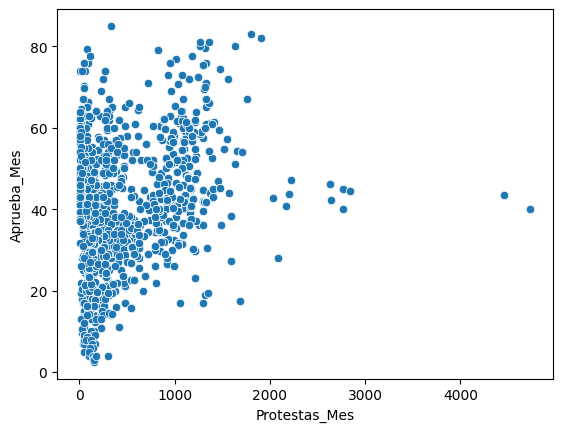

In [102]:
sns.scatterplot(data=df_ap_ps, x='Protestas_Mes', y='Aprueba_Mes')

In [103]:
df_ap_ps[['Protestas_Mes', 'Aprueba_Mes']].corr()

,Protestas_Mes,Aprueba_Mes
Protestas_Mes,1.00000,0.28709
Aprueba_Mes,0.28709,1.00000


<Axes: xlabel='Cantidad de Eventos de Protesta', ylabel='Aprueba'>

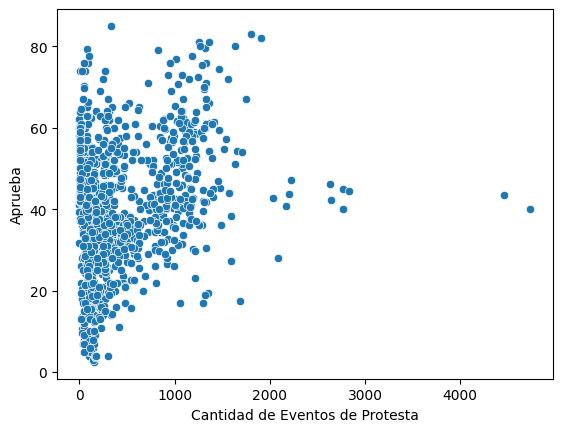

In [104]:
sns.scatterplot(data=df_ap_ps_2, x='Cantidad de Eventos de Protesta', y='Aprueba')

In [105]:
df_ap_ps_2[['Cantidad de Eventos de Protesta', 'Aprueba']].corr()

,Cantidad de Eventos de Protesta,Aprueba
Cantidad de Eventos de Protesta,1.000000,0.292234
Aprueba,0.292234,1.000000


## Visualizaciones

In [ ]:
# no me trae los totales correspondientes a protestas sociales por mes

In [61]:
# Hacer visualizaciones filtrando por Región, País, Presidente, etc.

# Filtrado de Regiones dentro del df.

regions_to_plot = ['América del Norte']

df_filtered = df_ap_ps[df_ap_ps['Región II'].isin(regions_to_plot)]

# Filtrado de Países dentro del df.

countries_to_plot = ['Argentina', 'Uruguay']

df_filtered_1 = df_ap_ps[df_ap_ps['País'].isin(countries_to_plot)]

# Filtrado de Presidentes dentro del df.

president_to_plot = ['Javier Milei', 'Luis Lacalle Pou']

df_filtered_2 = df_ap_ps[df_ap_ps['Presidente'].isin(president_to_plot)]

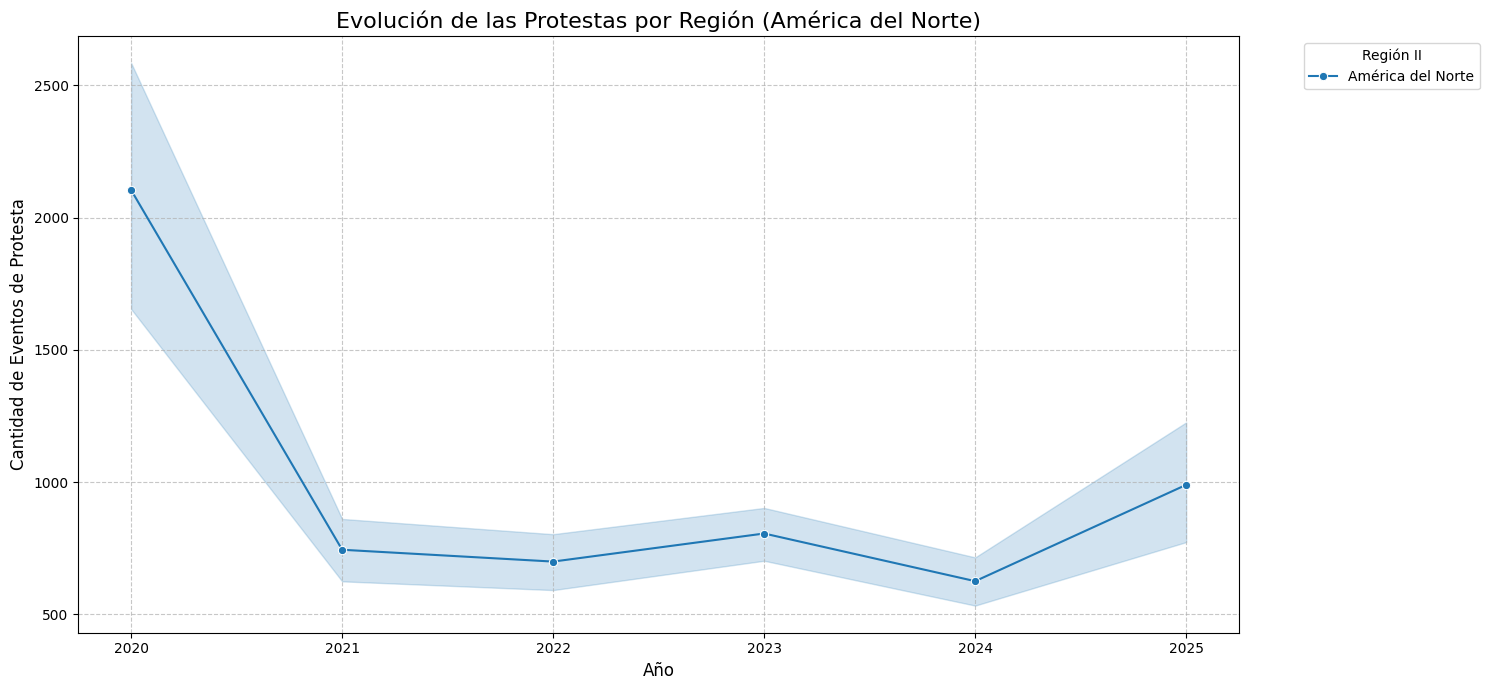

In [62]:
df_filtered = df_filtered.sort_values(by='Año')

plt.figure(figsize=[15, 7])
sns.lineplot(data=df_filtered, x='Año', y='Cantidad de Eventos de Protesta', hue='Región II', marker='o') # 'marker' para resaltar cada punto de dato

plt.title(f'Evolución de las Protestas por Región ({", ".join(regions_to_plot)})', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Eventos de Protesta', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Región II', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda fuera del gráfico
plt.tight_layout() # Ajusta el layout para que todo quepa
plt.show()

# Guardado y descarga de los Dataframes

In [ ]:
# Guardado del dataframe Aprobación Social en formato excel.

df_ap.to_excel('df.ap.xlsx', index=False)

In [ ]:
# Guardado del dataframe Protesta Social en formato excel.

df_ps.to_excel('df_ps.xlsx', index=False)

In [77]:
# Guardado del dataframe unificado AP-PS en formato excel.

df_ap_ps.to_excel('df_ap_ps.xlsx', index=False)
